In [16]:
import matplotlib as mpl
import shutil

shutil.rmtree(mpl.get_cachedir(), ignore_errors=True)
print("캐시 삭제 완료 → 커널 재시작하세요.")


캐시 삭제 완료 → 커널 재시작하세요.


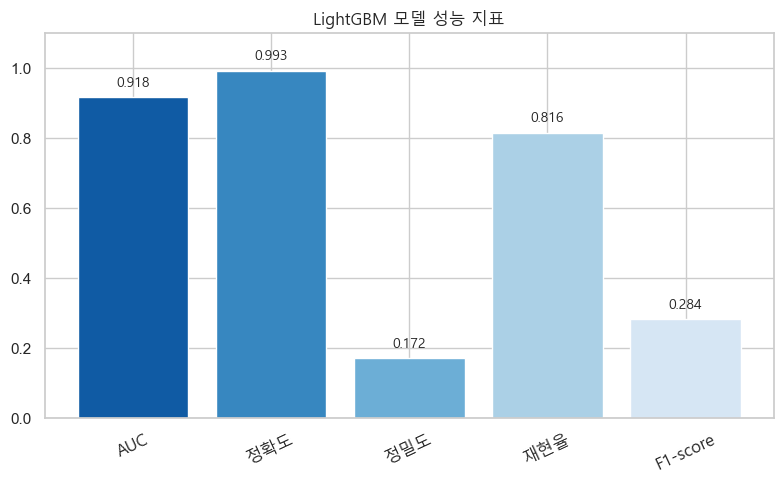

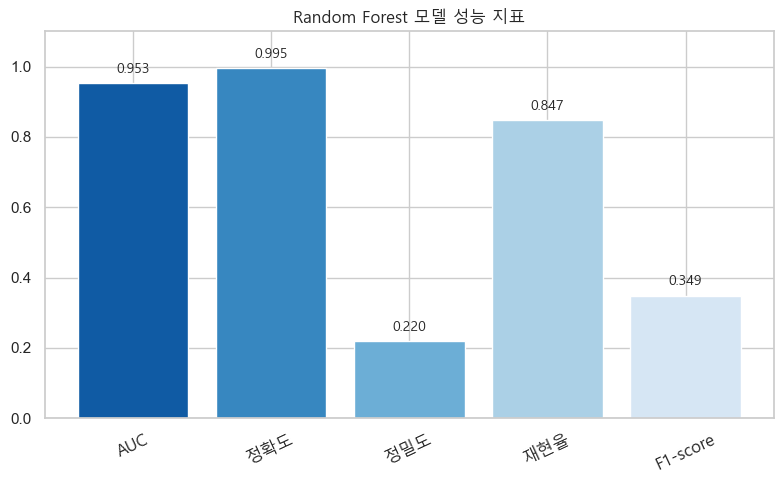

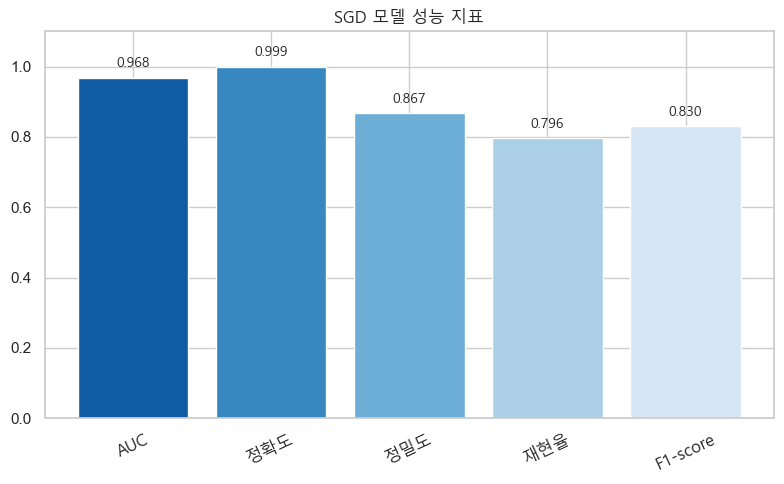

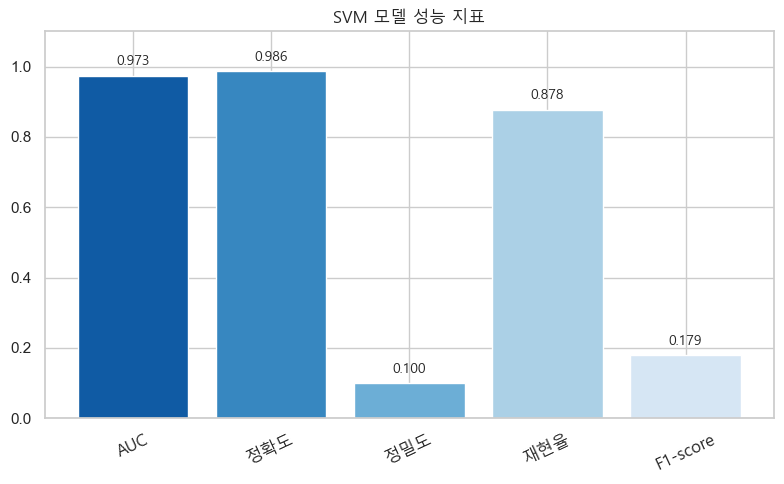

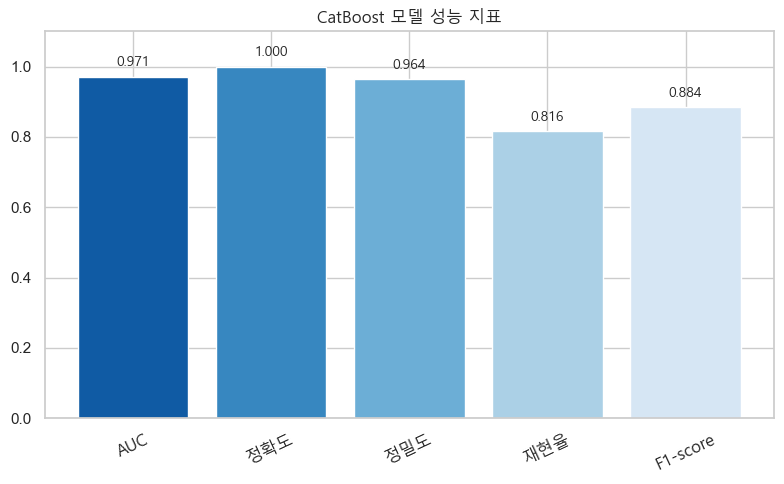

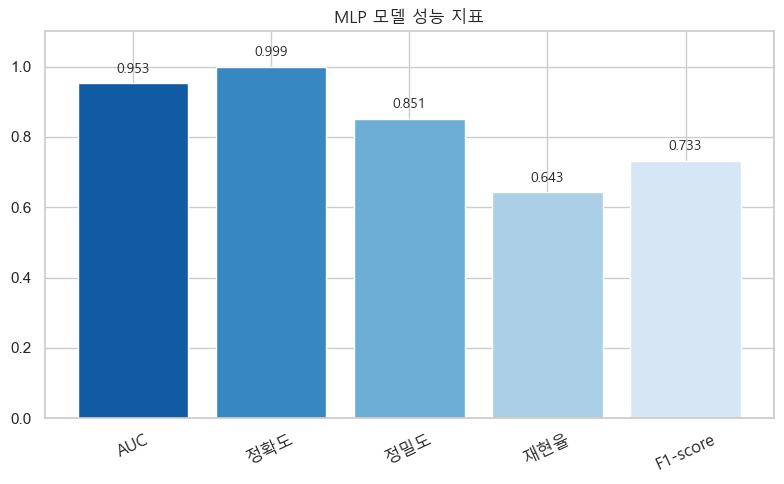

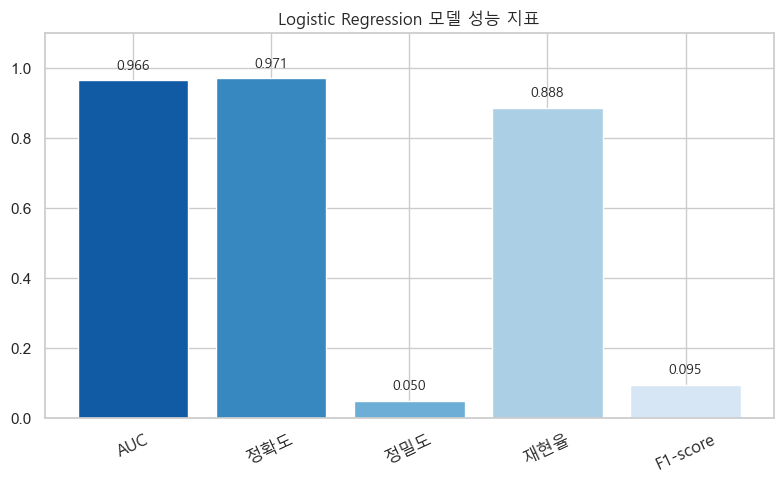

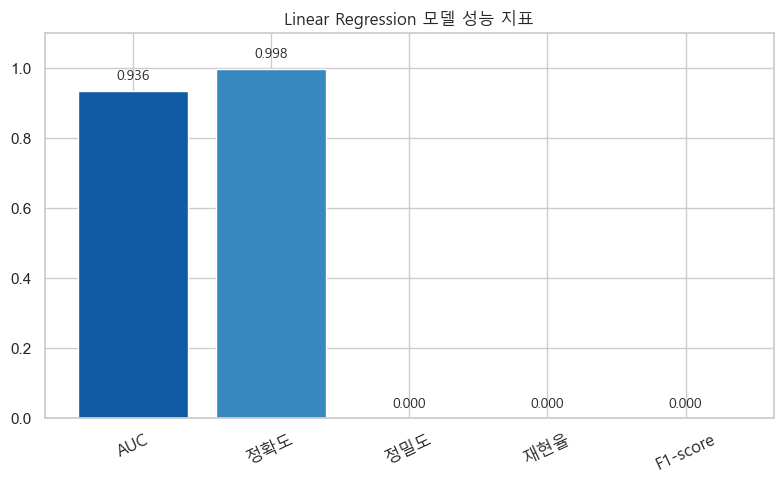

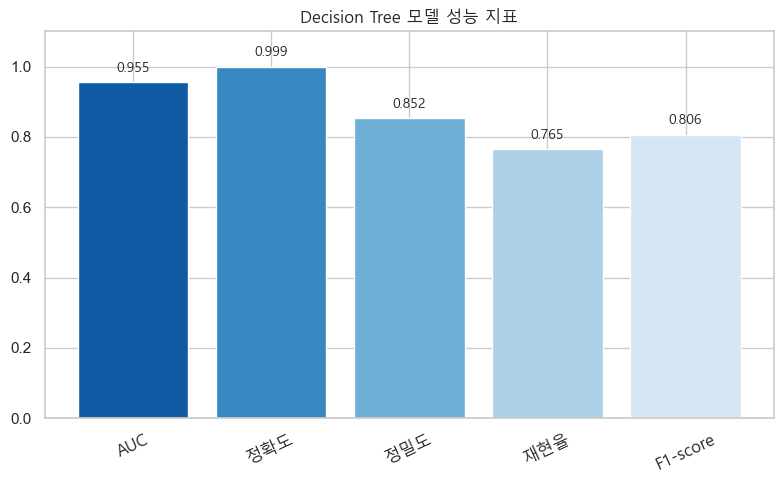

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager

# ---------------------------
# 🔧 폰트 설정
# ---------------------------
font_path = "C:/Windows/Fonts/malgun.ttf"
font_prop = font_manager.FontProperties(fname=font_path)

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['font.sans-serif'] = ['Malgun Gothic'] 
plt.rcParams['axes.unicode_minus'] = False


# ---------------------------
# 📌 데이터
# ---------------------------
data = {
    "모델": [
        "LightGBM", "Random Forest", "SGD", "SVM", "CatBoost",
        "MLP", "Logistic Regression", "Linear Regression", "Decision Tree"
    ],
    "AUC": [0.9179, 0.9526, 0.9680, 0.9733, 0.9707, 0.9528, 0.9657, 0.9358, 0.9552],
    "정확도": [0.9929, 0.9946, 0.9994, 0.9862, 0.9996, 0.9992, 0.9710, 0.9983, 0.9994],
    "정밀도": [0.1717, 0.2196, 0.8667, 0.0998, 0.9639, 0.8514, 0.0504, 0.0, 0.8523],
    "재현율": [0.8163, 0.8469, 0.7959, 0.8776, 0.8163, 0.6429, 0.8878, 0.0, 0.7653],
    "F1-score": [0.2837, 0.3487, 0.8298, 0.1792, 0.8840, 0.7326, 0.0954, 0.0, 0.8065]
}

df = pd.DataFrame(data)

sns.set(style="whitegrid")
metrics = ["AUC", "정확도", "정밀도", "재현율", "F1-score"]


# ---------------------------
# 📊 모델별 그래프 생성
# ---------------------------
for _, row in df.iterrows():
    plt.figure(figsize=(8, 5))

    model = row["모델"]
    values = row[metrics].astype(float)

    bars = plt.bar(metrics, values, color=sns.color_palette("Blues_r", len(metrics)))

    for bar in bars:
        y = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, y + 0.03, f"{y:.3f}",
                 ha='center', fontsize=10, weight="bold", fontproperties=font_prop)

    plt.title(f"{model} 모델 성능 지표", fontsize=16, weight="bold", fontproperties=font_prop)
    plt.ylim(0, 1.1)
    plt.xticks(rotation=25, fontproperties=font_prop)
    plt.tight_layout()
    plt.show()
